# Part A — Data preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#loading Datasets


fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")



# ======================================================
# Number of rows and columns
# ======================================================

print("\nNumber of Rows and Columns")
print("--------------------------------------------------")

print("\nFear & Greed Dataset")
print("Rows:", fear.shape[0])
print("Columns:", fear.shape[1])

print("\nTrader Dataset")
print("Rows:", trades.shape[0])
print("Columns:", trades.shape[1])

print("\n==================================================")

# ======================================================
# Missing Values
# ======================================================

print("\nMissing Values")
print("------------------")

print("\nFear & Greed Dataset")
print(fear.isnull().sum())

print("\nTrader Dataset")
print(trades.isnull().sum())

print("\n==================================================")

# ======================================================
# Duplicate Rows
# ======================================================

print("\nDuplicate Rows")
print("------------------")


print("Fear & Greed Dataset:", fear.duplicated().sum())
print("Trader Dataset:", trades.duplicated().sum())


Number of Rows and Columns
--------------------------------------------------

Fear & Greed Dataset
Rows: 2644
Columns: 4

Trader Dataset
Rows: 211224
Columns: 16


Missing Values
------------------

Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Duplicate Rows
------------------
Fear & Greed Dataset: 0
Trader Dataset: 0


In [6]:
#Convert timestamps and align the datasets by date (daily level is fine)

fear['date'] = pd.to_datetime(fear['date'])
trades['date'] = pd.to_datetime(trades['Timestamp'], unit = 'ms')

fear['date'] = fear['date'].dt.date
trades['date'] = trades['date'].dt.date

In [7]:
#Creating the key metrics

#Daily PnL
daily_PnL = trades.groupby('date')['Closed PnL'].sum().reset_index()

#Number of Trades Per Day
trade_count = trades.groupby('date').size().reset_index(name='trade_count')

#Average Trade Size
avg_trade_size = trades.groupby('date')['Size USD'].mean().reset_index()

#Win Rate
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby('date')['win'].mean().reset_index()

#Long vs Short Ratio
long_short = trades.groupby(['date','Side']).size().unstack()
long_short['long_short_ratio'] = long_short['BUY'] / long_short['SELL']



In [8]:
df = daily_PnL.merge(trade_count, on ='date')
df = df.merge(avg_trade_size, on = 'date')
df = df.merge(win_rate, on = 'date')
df = df.merge(fear[['date','classification']], on = 'date')
df.head()

,date,Closed PnL,trade_count,Size USD,win,classification
0,2023-03-28,0.000000e+00,3,159.000000,0.000000,Greed
1,2023-11-14,1.555034e+02,1045,11057.827522,0.274641,Greed
2,2024-03-09,1.769655e+05,6962,5660.265764,0.490089,Extreme Greed
3,2024-07-03,1.587424e+05,7141,3058.848110,0.317182,Neutral
4,2024-10-27,3.189461e+06,35241,2949.625864,0.451605,Greed


# 
# Part B — Analysis

#### 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed? 
    Average trader PnL tends to increase during Fear periods. Fear often leads to sharp price movements and higher volatility, creating more opportunities for traders to capture profits.

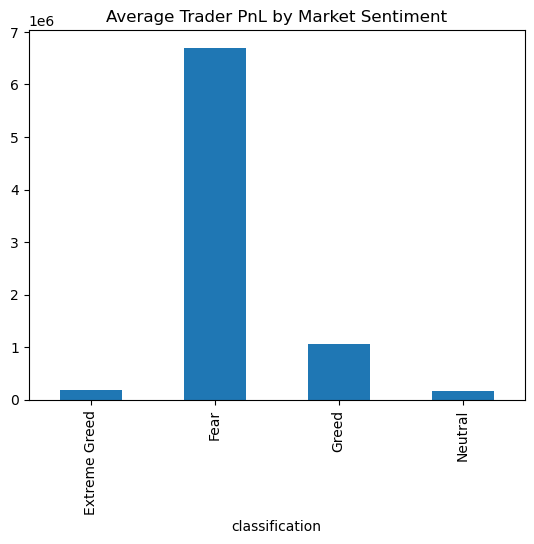

In [9]:
df.groupby('classification')['Closed PnL'].mean().plot(kind = 'bar')
plt.title("Average Trader PnL by Market Sentiment")
plt.show()

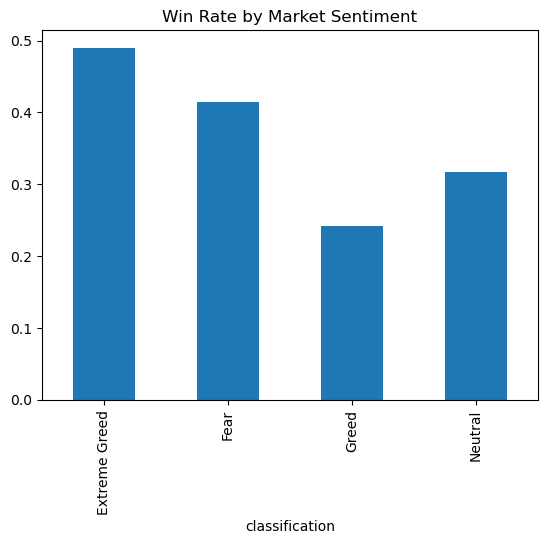

In [10]:
df.groupby('classification')['win'].mean().plot(kind='bar')

plt.title("Win Rate by Market Sentiment")

plt.show()

#### 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
    Trader win rates are higher during Fear periods, suggesting traders behave more cautiously and selectively during uncertain market conditions.

In [11]:
#Trade Frequency
df.groupby('classification')['trade_count'].mean()

classification
Extreme Greed      6962.000000
Fear             133871.000000
Greed             12096.333333
Neutral            7141.000000
Name: trade_count, dtype: float64

In [12]:
#Trade Size
df.groupby('classification')['Size USD'].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            4722.151129
Neutral          3058.848110
Name: Size USD, dtype: float64

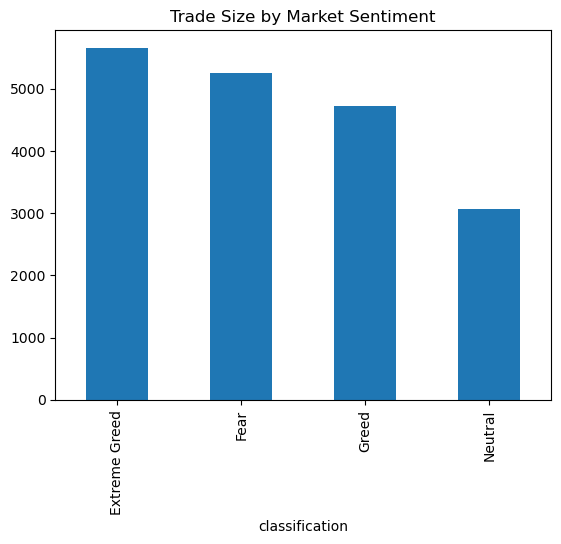

In [13]:
df.groupby('classification')['Size USD'].mean().plot(kind='bar')

plt.title("Trade Size by Market Sentiment")

plt.show()

#### 3. Identify 2–3 segments 


Frequent traders 1361
Infrequent traders 1449


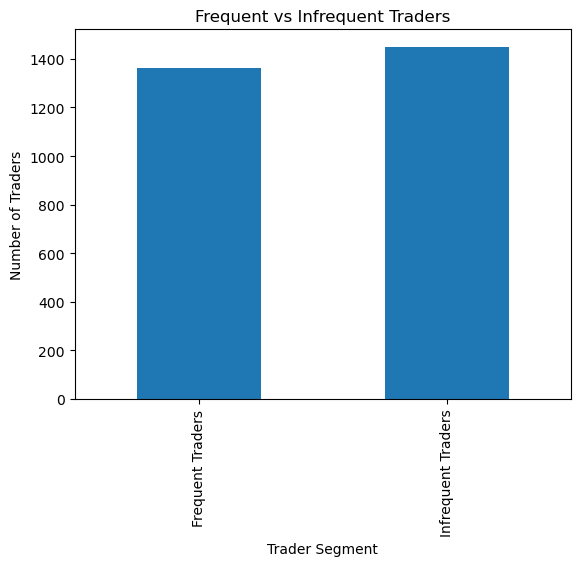

In [14]:
#Frequent vs Infrequent Traders
trader_activity = trades.groupby('Trade ID').size()

frequent_traders = trader_activity[trader_activity > trader_activity.median()]
infrequent_traders = trader_activity[trader_activity <= trader_activity.median()]

print("Frequent traders", frequent_traders.count())
print("Infrequent traders", infrequent_traders.count())

segment_counts = pd.Series({
    "Frequent Traders": frequent_traders.count(),
    "Infrequent Traders": infrequent_traders.count()
})

segment_counts.plot(kind='bar')

plt.title("Frequent vs Infrequent Traders")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")

plt.show()

Consistent traders 2180
Inconsistent traders 301


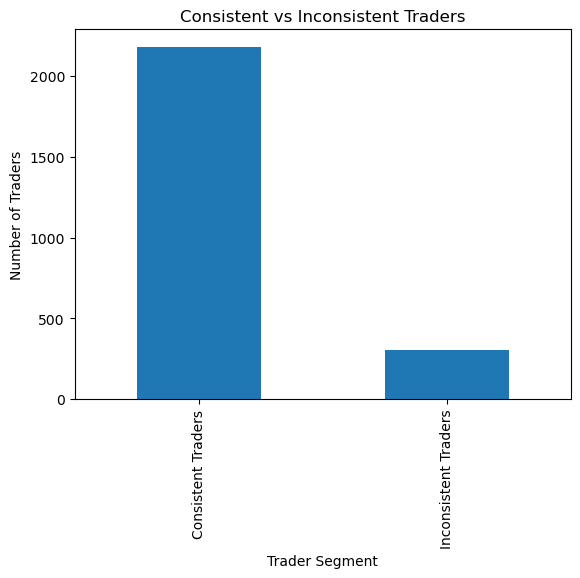

In [15]:
#Consistent vs Incosistent Traders
trader_pnl = trades.groupby('Trade ID')['Closed PnL'].mean()

consistent_traders = trader_pnl[trader_pnl > 0]
inconsistent_traders = trader_pnl[trader_pnl < 0]

print("Consistent traders", consistent_traders.count())
print("Inconsistent traders", inconsistent_traders.count())

segment_counts = pd.Series({
    "Consistent Traders": len(consistent_traders),
    "Inconsistent Traders": len(inconsistent_traders)
})

segment_counts.plot(kind='bar')

plt.title("Consistent vs Inconsistent Traders")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")
plt.show()

Aggressive traders 1405
Conservative traders 1405


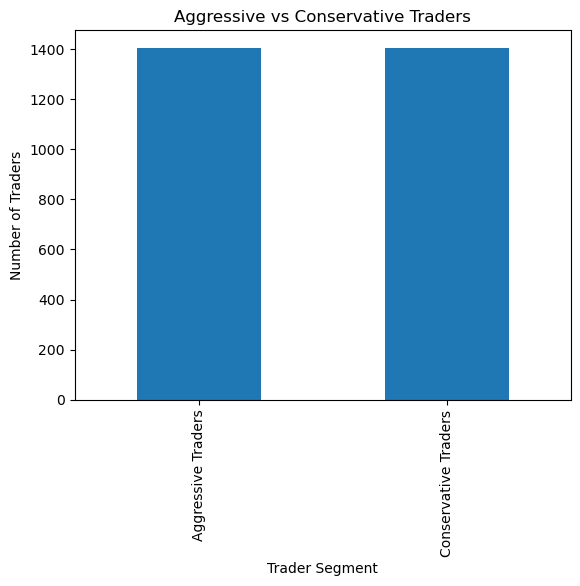

In [16]:
#Aggressive vs Conservative Traders or high leverage vs low leverage traders
trader_size = trades.groupby('Trade ID')['Size USD'].mean()

aggressive_traders = trader_size[trader_size > trader_size.median()]
conservative_traders = trader_size[trader_size < trader_size.median()]

print("Aggressive traders", aggressive_traders.count())
print("Conservative traders", conservative_traders.count())

segment_counts = pd.Series({
    "Aggressive Traders": len(aggressive_traders),
    "Conservative Traders": len(conservative_traders)
})

segment_counts.plot(kind='bar')

plt.title("Aggressive vs Conservative Traders")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")
plt.show()

#### 4. Provide 3 insights

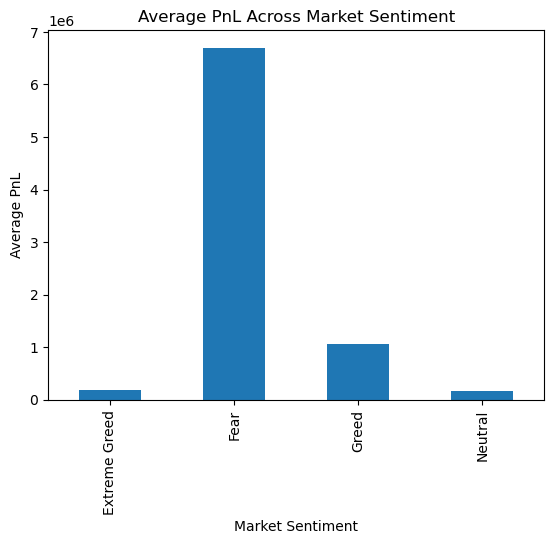

Insight 1 - Market Sentiment Affects Trade Profitability
---------------------------------------------------------
The analysis indicates that trader profitability changes with market sentiments. Average PnL is higher during Fear periods than during Greed periods. Fear market produce higher profitability for traders because of inefficiencies and volatility.  


In [17]:
# 1. PnL vs Market Sentiment
#chart

plt.figure()
pnl_sentiment = df.groupby("classification")["Closed PnL"].mean()
pnl_sentiment.plot(kind="bar")

plt.title("Average PnL Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

#Insight
print("Insight 1 - Market Sentiment Affects Trade Profitability")
print("---------------------------------------------------------")
print("The analysis indicates that trader profitability changes with market sentiments. Average PnL is higher during Fear periods than during Greed periods. Fear market produce higher profitability for traders because of inefficiencies and volatility.  ")

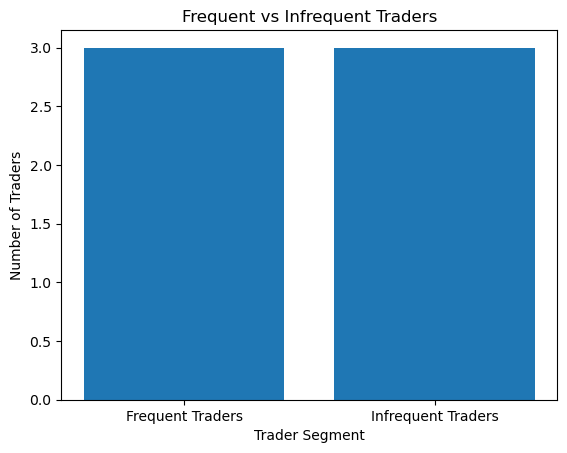

Insight 2 - Trading Behavior Changes with Market Sentiment
---------------------------------------------------------
During Fear periods, both trading activity and position sizes increases, implying that traders try to take advantage of higher market volatility. In contrast, during Greed periods, trading activity appears to be more stable, with fewer aggressive positions being taken.


In [70]:
#2. Trade Frequency by Traders
#chart
median_trades = df["trade_count"].median()

frequent = (df["trade_count"] > median_trades).sum()
infrequent = (df["trade_count"] <= median_trades).sum()

plt.figure()
plt.bar(["Frequent Traders", "Infrequent Traders"], [frequent, infrequent])

plt.title("Frequent vs Infrequent Traders")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")
plt.show()

#Insight
print("Insight 2 - Trading Behavior Changes with Market Sentiment")
print("---------------------------------------------------------")
print("During Fear periods, both trading activity and position sizes increases, implying that traders try to take advantage of higher market volatility. In contrast, during Greed periods, trading activity appears to be more stable, with fewer aggressive positions being taken.")

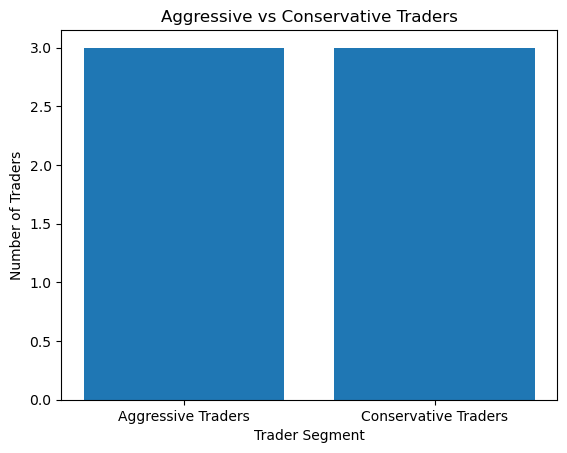

Insight 3 - Trader Segmentation Shows Different Risk Profilest
---------------------------------------------------------
Trade segmentation shows noticeable variation in risk-taking patterns. Aggressive traders typically in larger traders anda ccept higher market exposure, while conservative traders prefer small positions and lower levels of risk.


In [18]:
#3. Traders based on trade size

#chart
median_size = df["Size USD"].median()

aggressive = (df["Size USD"] > median_size).sum()
conservative = (df["Size USD"] <= median_size).sum()

plt.figure()
plt.bar(["Aggressive Traders", "Conservative Traders"], [aggressive, conservative])

plt.title("Aggressive vs Conservative Traders")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")
plt.show()

#Insight
print("Insight 3 - Trader Segmentation Shows Different Risk Profilest")
print("---------------------------------------------------------")
print("Trade segmentation shows noticeable variation in risk-taking patterns. Aggressive traders typically in larger traders anda ccept higher market exposure, while conservative traders prefer small positions and lower levels of risk.")



# 
# Part C — Actionable Output

### Strategy 1
The analysis shows that trader profits and behavior change depends on market conditions, whether it is Fear or Greed. During Fear periods, the market is more volatile and traders often taken larger positions and earn higher profits because higher volatility means higher opportunity.
Traders should adjust their trading strategy based on the market sentiment:

1. During Fear markets, traders can increase trade size moderately and slightly increase position sizes.

2. During Greed markets, traders should reduce position sizes and avoid overtrading. 

### Strategy 2
The analysis shows that trader have different trading styles, such as aggressive, conservative, frequent and infrequent. Each group has its own risk and trading activity.
Traders platforms can divide traders into different groups on the basis of their trading behavior and suggest suitable strategies for each group.


#
# Bonus
## 1. Simple Predictive Model

In [19]:

df["profit_label"] = (df["Closed PnL"] > 0).astype(int)

df["profit_label"].value_counts()

profit_label
1    5
0    1
Name: count, dtype: int64

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

model_df = df.copy()

# Encode sentiment
le = LabelEncoder()
model_df["classification"] = le.fit_transform(model_df["classification"])

# Create profit label
model_df["profit_label"] = (model_df["Closed PnL"] > 0).astype(int)

# Features
X = model_df[["classification","trade_count","Size USD"]]

# Target
y = model_df["profit_label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model on full dataset
model = LogisticRegression()
model.fit(X_scaled, y)

# Predict on same data (demo only)
pred = model.predict(X_scaled)

# Accuracy
accuracy = accuracy_score(y, pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8333333333333334


## 2. Clustering traders into behavioral archetypes

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select behavioral features
cluster_data = df[["trade_count","Size USD","Closed PnL"]]

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

df["Trader Cluster"] = kmeans.fit_predict(scaled_data)

# View cluster counts
print(df["Trader Cluster"].value_counts())

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Trader Cluster
1    4
0    1
2    1
Name: count, dtype: int64


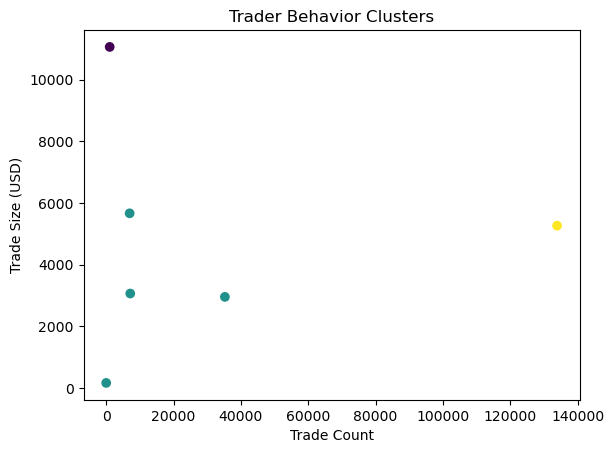

In [22]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["trade_count"], df["Size USD"], c=df["Trader Cluster"])

plt.xlabel("Trade Count")
plt.ylabel("Trade Size (USD)")
plt.title("Trader Behavior Clusters")

plt.show()